In [1]:
import torch, time, sys, math
import torch.nn.functional as F
sys.path.insert(0, '/root/project/scripts')

import _3dgs._3dgs as _mod
_mod.USE_CUDA_KERNEL = True
_mod._load_3dgs_kernel()

from _3dgs._3dgs import GaussianCloud, AABB, VolumeDataset, _ssim_sample_pts
import argparse, tifffile, numpy as np

cfg = argparse.Namespace(
    scale_min_clamp=1e-5, mahal_max_clamp=20.0, init_scale=0.05,
    init_inten=0.1, init_scale_z_factor=1.0, n_init=5000,
    swc_path=None, chunk_n=5000, eval_samples=200_000,
    ssim_crop=64, batch=2048,
    grad_sample_weight=0.0, lambda_ssim=0.2,
)
device  = torch.device('cuda')
vol_np  = tifffile.imread('/root/project/data/fafb/blocks/image_z0_y0_x0.tif').astype('float32') / 255.
volume  = torch.from_numpy(vol_np)
aabb    = AABB.unit()
dataset = VolumeDataset(volume, aabb, cfg)
gc      = GaussianCloud(5000, aabb, device, cfg)

def timeit(label, fn, n=30):
    for _ in range(5): fn()
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n): fn()
    torch.cuda.synchronize()
    ms = (time.perf_counter() - t0) / n * 1000
    print(f"  {label:<56s}  {ms:6.2f} ms")
    return ms

pts_train, gt_train, _ = dataset.sample(2048,    device, cfg=cfg)
pts_eval,  gt_eval,  _ = dataset.sample(200_000, device, cfg=cfg)
ssim_pts, ssim_gt       = _ssim_sample_pts(aabb, dataset, cfg, device)
fused_pts               = torch.cat([pts_train, ssim_pts], dim=0)   # 2048+4096=6144

print(f"CUDA kernel: {_mod.USE_CUDA_KERNEL}   N={gc.N}   chunk_n={cfg.chunk_n}   "
      f"free GPU: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")
print()
print("━━  Per-step costs (N=5000, chunk_n=5000)  ━━")
t_fwd   = timeit("forward  2048 pts             (training only)",
                 lambda: gc.forward(pts_train, chunk_n=5000))
t_fused = timeit("forward  6144 pts             (fused train+SSIM)",
                 lambda: gc.forward(fused_pts, chunk_n=5000))
t_bwd   = timeit("backward 6144 pts  v2 kernel  (fused, w/ grad)",
                 lambda: gc.forward(fused_pts, chunk_n=5000).mean().backward())

print()
print("━━  Per-epoch eval (no_grad, CUDA kernel, chunk_n=5000)  ━━")
with torch.no_grad():
    t_ev200 = timeit("PSNR eval 200k pts  chunk_n=5000",
                     lambda: gc.forward(pts_eval, chunk_n=5000), n=10)

print()
print("━━  Epoch budget (50 steps, fused SSIM, v2 backward, chunk_n=5000)  ━━")
bwd_only  = t_bwd - t_fused          # backward-only time (fused bwd includes forward)
step_ms   = t_fused + bwd_only       # = t_bwd
total_ms  = 50 * step_ms + t_ev200
rows = [
    ("forward+SSIM fused × 50",  50 * t_fused,  "single kernel call"),
    ("backward v2        × 50",  50 * bwd_only,  "N=5000 blocks, warp-shuffle"),
    ("PSNR eval 200k     × 1",   t_ev200,        "no_grad, chunk_n=5000"),
]
for name, ms, note in rows:
    print(f"  {name:<28s}  {ms:6.0f} ms  ({100*ms/total_ms:.0f}%)  ← {note}")
print(f"  {'total (est)':<28s}  {total_ms:6.0f} ms  →  {1000/total_ms:.2f} ep/s")


/venv/r3-ml/lib/python3.11/site-packages/torch/utils/cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


CUDA kernel: True   N=5000   chunk_n=5000   free GPU: 33.39 GB

━━  Per-step costs (N=5000, chunk_n=5000)  ━━
  forward  2048 pts             (training only)               0.57 ms
  forward  6144 pts             (fused train+SSIM)            0.58 ms
  backward 6144 pts  v2 kernel  (fused, w/ grad)              0.70 ms

━━  Per-epoch eval (no_grad, CUDA kernel, chunk_n=5000)  ━━
  PSNR eval 200k pts  chunk_n=5000                            3.30 ms

━━  Epoch budget (50 steps, fused SSIM, v2 backward, chunk_n=5000)  ━━
  forward+SSIM fused × 50           29 ms  (76%)  ← single kernel call
  backward v2        × 50            6 ms  (16%)  ← N=5000 blocks, warp-shuffle
  PSNR eval 200k     × 1             3 ms  (9%)  ← no_grad, chunk_n=5000
  total (est)                       38 ms  →  26.21 ep/s


In [2]:
import torch, numpy as np

ckpt = torch.load("/root/project/models/z000_y000_x000/epoch_0800.pth", map_location="cpu", weights_only=True)
s = torch.exp(ckpt["log_scales"])   # (N, 3)

s_sorted, _ = s.sort(dim=-1)
s_min, s_mid, s_max = s_sorted[:, 0], s_sorted[:, 1], s_sorted[:, 2]
ratio = s_max / s_min

print(f"N = {s.shape[0]}")
print(f"\nScale magnitudes:")
print(f"  s_min  — mean {s_min.mean():.4f}  median {s_min.median():.4f}  p95 {s_min.quantile(0.95):.4f}")
print(f"  s_mid  — mean {s_mid.mean():.4f}  median {s_mid.median():.4f}  p95 {s_mid.quantile(0.95):.4f}")
print(f"  s_max  — mean {s_max.mean():.4f}  median {s_max.median():.4f}  p95 {s_max.quantile(0.95):.4f}")
print(f"\nAnisotropy ratio s_max/s_min:")
print(f"  mean {ratio.mean():.1f}  median {ratio.median():.1f}  p95 {ratio.quantile(0.95):.1f}  max {ratio.max():.1f}")
print(f"\n% ratio > 5:   {(ratio > 5).float().mean()*100:.1f}%")
print(f"% ratio > 10:  {(ratio > 10).float().mean()*100:.1f}%")
print(f"% ratio > 50:  {(ratio > 50).float().mean()*100:.1f}%")


FileNotFoundError: [Errno 2] No such file or directory: '/root/project/models/z000_y000_x000/epoch_0800.pth'

dict_keys(['means', 'log_scales', 'quats', 'intensities', 'inten_param'])
Loaded 50000 Gaussians from /root/project/models_smoke/block_z000_y001_x006/best.pth


Reconstructed volume shape: (50, 50, 50)  range: [0.046, 1.000]


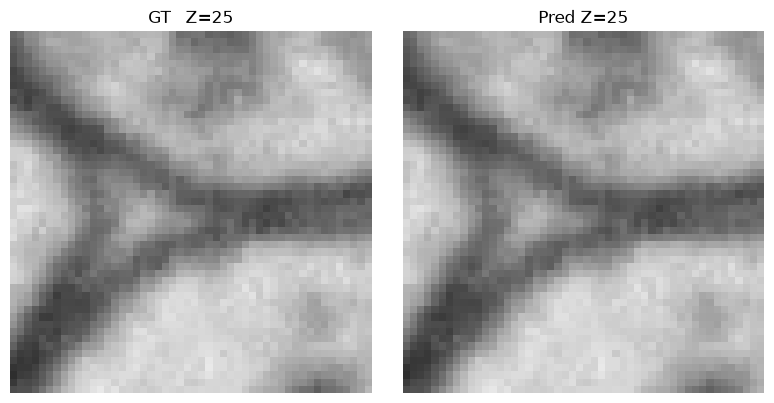

In [3]:
%matplotlib inline
# reconstruct the volume from the Gaussian cloud
import sys, argparse, torch, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0, '/root/project/scripts')

import _3dgs._3dgs as _mod
_mod.USE_CUDA_KERNEL = True
_mod._load_3dgs_kernel()
from _3dgs._3dgs import GaussianCloud, AABB, VolumeDataset
from _3dgs._3dgs_training import _load_volume

device = torch.device('cuda')

# smoke_data blocks are 50^3 (see configs/smoke_config.yml) -> ssim_crop must match
cfg = argparse.Namespace(
    scale_min_clamp=1e-5, mahal_max_clamp=20.0, init_scale=0.05,
    init_inten=0.1, init_scale_z_factor=1.0, n_init=5000,
    swc_path=None, chunk_n=1000, eval_samples=200_000,
    ssim_crop=50, batch=2048,
    grad_sample_weight=0.0, lambda_ssim=0.2,
)

# --- load GT volume (ground truth) ---
vol_t, _, _ = _load_volume('/root/project/data/smoke_data/blocks/block_z0_y1_x6.h5')
aabb    = AABB.unit()
dataset = VolumeDataset(vol_t, aabb, cfg)
D, H, W = dataset.D, dataset.H, dataset.W

# --- load model directly via GaussianCloud.load (handles the .pth checkpoint format) ---
ckpt_path = '/root/project/models_smoke/block_z000_y001_x006/best.pth'
print(torch.load(ckpt_path, map_location="cpu", weights_only=True).keys())   # sanity check
print(gc)
print(f"Loaded {gc.N} Gaussians from {ckpt_path}")

# --- reconstruct volume slice-by-slice ---
pred_vol = np.empty((D, H, W), dtype=np.float32)
with torch.no_grad():
    for z in range(D):
        pts = dataset._indices_to_pts(
            torch.full((H * W,), z, dtype=torch.long),
            torch.arange(H, dtype=torch.long).repeat_interleave(W),
            torch.arange(W, dtype=torch.long).tile(H),
            device,
        )
        pred = gc.forward(pts, chunk_n=cfg.chunk_n).clamp(0.0, 1.0)
        pred_vol[z] = pred.cpu().numpy().reshape(H, W)

print(f"Reconstructed volume shape: {pred_vol.shape}  range: [{pred_vol.min():.3f}, {pred_vol.max():.3f}]")

# --- visualise middle slice ---
mid = D // 2
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(vol_t[mid].numpy(), cmap='gray', vmin=0, vmax=1); axes[0].set_title(f"GT   Z={mid}"); axes[0].axis('off')
axes[1].imshow(pred_vol[mid],      cmap='gray', vmin=0, vmax=1); axes[1].set_title(f"Pred Z={mid}"); axes[1].axis('off')
plt.tight_layout(); plt.show()


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
model = torch.load("/root/project/models/z000_y000_x000/best.pth", map_location="cpu", weights_only=True)
means = model["means"].numpy()
scales = torch.exp(model["log_scales"]).numpy()
quats = model["quats"].numpy()
intensities = model["intensities"].numpy()

# eval the model


In [ ]:
import torch
import numpy as np

model = torch.load("/root/project/models/z000_y000_x000/best.pth", map_location="cpu", weights_only=True)

out_dir = "/root/project/models/z000_y000_x000"
np.save(f"{out_dir}/means.npy",       model["means"].numpy())
np.save(f"{out_dir}/scales.npy",      torch.exp(model["log_scales"]).numpy())
np.save(f"{out_dir}/quats.npy",       model["quats"].numpy())
np.save(f"{out_dir}/intensities.npy", model["intensities"].numpy())

print("Saved:")
for key, shape in [("means", model["means"].shape),
                   ("scales", model["log_scales"].shape),
                   ("quats", model["quats"].shape),
                   ("intensities", model["intensities"].shape)]:
    print(f"  {key}.npy  {tuple(shape)}")

In [ ]:
import sys, argparse, torch, tifffile, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0, '/root/project/scripts')

import _3dgs._3dgs as _mod
_mod.USE_CUDA_KERNEL = True
_mod._load_3dgs_kernel()
from _3dgs._3dgs import GaussianCloud, AABB, VolumeDataset

cfg = argparse.Namespace(
    scale_min_clamp=1e-5, mahal_max_clamp=20.0, init_scale=0.05,
    init_inten=0.1, init_scale_z_factor=1.0, n_init=5000,
    swc_path=None, chunk_n=5000, eval_samples=200_000, ssim_crop=64, batch=2048,
    grad_sample_weight=0.0, lambda_ssim=0.2,
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- load volume (ground truth) ---
vol_np  = tifffile.imread('/root/project/data/fafb/blocks/image_z0_y0_x0.tif').astype('float32') / 255.
volume  = torch.from_numpy(vol_np)
aabb    = AABB.unit()
dataset = VolumeDataset(volume, aabb, cfg)
D, H, W = dataset.D, dataset.H, dataset.W

# --- load model ---
ckpt_path = '/root/project/models/z000_y000_x000/best.pth'
gc = GaussianCloud.load(ckpt_path, aabb, device, cfg)
print(f"Loaded {gc.N} Gaussians from {ckpt_path}")

# --- reconstruct volume slice-by-slice ---
pred_vol = np.empty((D, H, W), dtype=np.float32)
with torch.no_grad():
    for z in range(D):
        pts = dataset._indices_to_pts(
            torch.full((H * W,), z, dtype=torch.long),
            torch.arange(H, dtype=torch.long).repeat_interleave(W),
            torch.arange(W, dtype=torch.long).tile(H),
            device,
        )
        pred = gc.forward(pts, chunk_n=cfg.chunk_n).clamp(0.0, 1.0)
        pred_vol[z] = pred.cpu().numpy().reshape(H, W)

print(f"Reconstructed volume shape: {pred_vol.shape}  range: [{pred_vol.min():.3f}, {pred_vol.max():.3f}]")

# --- visualise middle slices (XY, XZ, YZ) ---
mid = D // 2
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col, (gt_sl, pred_sl, title) in enumerate([
    (vol_np[mid],        pred_vol[mid],        f"Z={mid}  (XY)"),
    (vol_np[:, mid, :],  pred_vol[:, mid, :],  f"Y={mid}  (XZ)"),
    (vol_np[:, :, mid],  pred_vol[:, :, mid],  f"X={mid}  (YZ)"),
]):
    axes[0, col].imshow(gt_sl,   cmap='gray', vmin=0, vmax=1); axes[0, col].set_title(f"GT  {title}");   axes[0, col].axis('off')
    axes[1, col].imshow(pred_sl, cmap='gray', vmin=0, vmax=1); axes[1, col].set_title(f"Pred {title}"); axes[1, col].axis('off')
plt.tight_layout(); plt.show()

# --- save ---
np.save('/root/project/models/z000_y000_x000/pred_vol.npy', pred_vol)
print("Saved pred_vol.npy")

In [ ]:
import numpy as np 
vol = np.load('/root/project/models/z000_y000_x000/pred_vol.npy')

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.imshow(vol[vol.shape[0]//2], cmap='gray')

In [1]:
import sys, argparse, math, torch, tifffile, numpy as np, matplotlib.pyplot as plt

sys.path.insert(0, '/root/project/scripts')
import _3dgs._3dgs as _mod
_mod.USE_CUDA_KERNEL = True
_mod._load_3dgs_kernel()
from _3dgs._3dgs import GaussianCloud, AABB, VolumeDataset, _load_eval_kernel

# ── setup ─────────────────────────────────────────────────────────────────────
cfg = argparse.Namespace(
    scale_min_clamp=1e-5, mahal_max_clamp=20.0, init_scale=0.05,
    init_inten=0.1, init_scale_z_factor=1.0, n_init=5000,
    swc_path=None, chunk_n=5000, eval_samples=200_000, ssim_crop=64,
    batch=2048, grad_sample_weight=0.0, lambda_ssim=0.2,
)
device = torch.device('cuda')

vol_np  = tifffile.imread('/root/project/data/fafb/blocks/image_z0_y0_x0.tif').astype('float32') / 255.
aabb    = AABB.unit()
dataset = VolumeDataset(torch.from_numpy(vol_np), aabb, cfg)
D, H, W = dataset.D, dataset.H, dataset.W

# ── load best.pth directly into GaussianCloud ─────────────────────────────────
gc = GaussianCloud.load('/root/project/models/z000_y000_x000/best.pth', aabb, device, cfg)
print(f"Loaded {gc.N} Gaussians")

kernel     = _load_eval_kernel()
lo         = gc.aabb.lo.cpu()
hi         = gc.aabb.hi.cpu()
lo_x, hi_x = float(lo[0]), float(hi[0])
lo_y, hi_y = float(lo[1]), float(hi[1])
lo_z, hi_z = float(lo[2]), float(hi[2])
scale_min   = float(gc.scale_min)
mahal_clamp = float(gc.mahal_clamp)

# ── helpers: rotate means and quaternions around the Y axis ──────────────────
def rot_y_matrix(theta):
    """3×3 rotation matrix around Y axis by theta radians."""
    c, s = math.cos(theta), math.sin(theta)
    return torch.tensor([[c, 0, s], [0, 1, 0], [-s, 0, c]],
                        dtype=torch.float32, device=device)

def quat_mul(q1, q2):
    """Hamilton product of (N,4) quaternions [w,x,y,z]."""
    w1, x1, y1, z1 = q1[:,0], q1[:,1], q1[:,2], q1[:,3]
    w2, x2, y2, z2 = q2[:,0], q2[:,1], q2[:,2], q2[:,3]
    return torch.stack([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
    ], dim=1)

def splat_mip_rotated(azimuth_deg, depth_samples=64, out_h=256, out_w=256):
    """
    Rotate all Gaussians around Y by azimuth_deg, then call splat_mip
    looking down Z (view_axis=0). Equivalent to a camera at the block
    centre rotating around its own Y axis.
    """
    theta = math.radians(azimuth_deg)
    R     = rot_y_matrix(theta)

    # rotate means: (N,3) @ R^T
    means_rot = (gc.means.detach() @ R.T).contiguous()

    # compose quaternions: q_rot * q_gaussian
    # rotation around Y by theta -> quat [cos(θ/2), 0, sin(θ/2), 0]
    half = theta / 2.0
    q_rot = torch.tensor([[math.cos(half), 0.0, math.sin(half), 0.0]],
                         dtype=torch.float32, device=device).expand(gc.N, -1)
    quats_rot = quat_mul(q_rot, gc.quats.detach()).contiguous()

    flat = kernel.splat_mip(
        means_rot, gc.log_s.detach().contiguous(),
        quats_rot, gc.inten.detach().contiguous(),
        lo_x, hi_x, lo_y, hi_y, lo_z, hi_z,
        out_h, out_w, depth_samples, 0,   # view_axis=0: looking down Z
        scale_min, mahal_clamp,
    )
    return flat.reshape(out_h, out_w).cpu().numpy()

# ── render 8 views at 45° steps ───────────────────────────────────────────────
azimuths = np.arange(0, 360, 45)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, az in zip(axes.ravel(), azimuths):
    frame = splat_mip_rotated(az, depth_samples=64, out_h=256, out_w=256)
    ax.imshow(frame, cmap='gray', vmin=0, vmax=1, interpolation='bilinear')
    ax.set_title(f'az={az}°', fontsize=10)
    ax.axis('off')
plt.suptitle('MIP splatting — camera at centre, rotating around Y axis', fontsize=12)
plt.tight_layout()
plt.show()
print("Done.")

/venv/r3-ml/lib/python3.11/site-packages/torch/utils/cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
/root/project/scripts/_3dgs/_3dgs.py:1008: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start 